# Продвинутый анализ моделей


|раздел | [nixtla](https://nixtlaverse.nixtla.io/statsforecast/) | [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|

https://otexts.com/fpppy/nbs/13-practical.html

## Импорт

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [14]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [15]:
from scipy import stats
import pmdarima as pm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss

import statsmodels.api as sm

In [53]:
from pandas.tseries.frequencies import to_offset

In [4]:
# def matplotlib2GOST:
plt.rcParams.update({
    # ШРИФТ
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 11,                      # ГОСТ: 10–12 pt

    # ОСИ И ПОДПИСИ
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,

    # РАЗМЕР ФИГУРЫ (A4, отчёты)
    # "figure.figsize": (6.5, 4.0),         # ~16.5 × 10 см
    "figure.figsize": (12, 3.0),         
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # СОХРАНЕНИЕ
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,

    # ЛИНИИ И ОСИ
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "lines.linewidth": 1.5,
    "patch.linewidth": 1.0,

    # СЕТКА
    "axes.grid": True,                   # ГОСТ: обычно без сетки
    "axes.axisbelow": True,

    # TEX
    "text.usetex": False,
})


In [5]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [6]:
from functools import partial

## Загрузка данных

Импорт данных аналогично предыдущего урока.

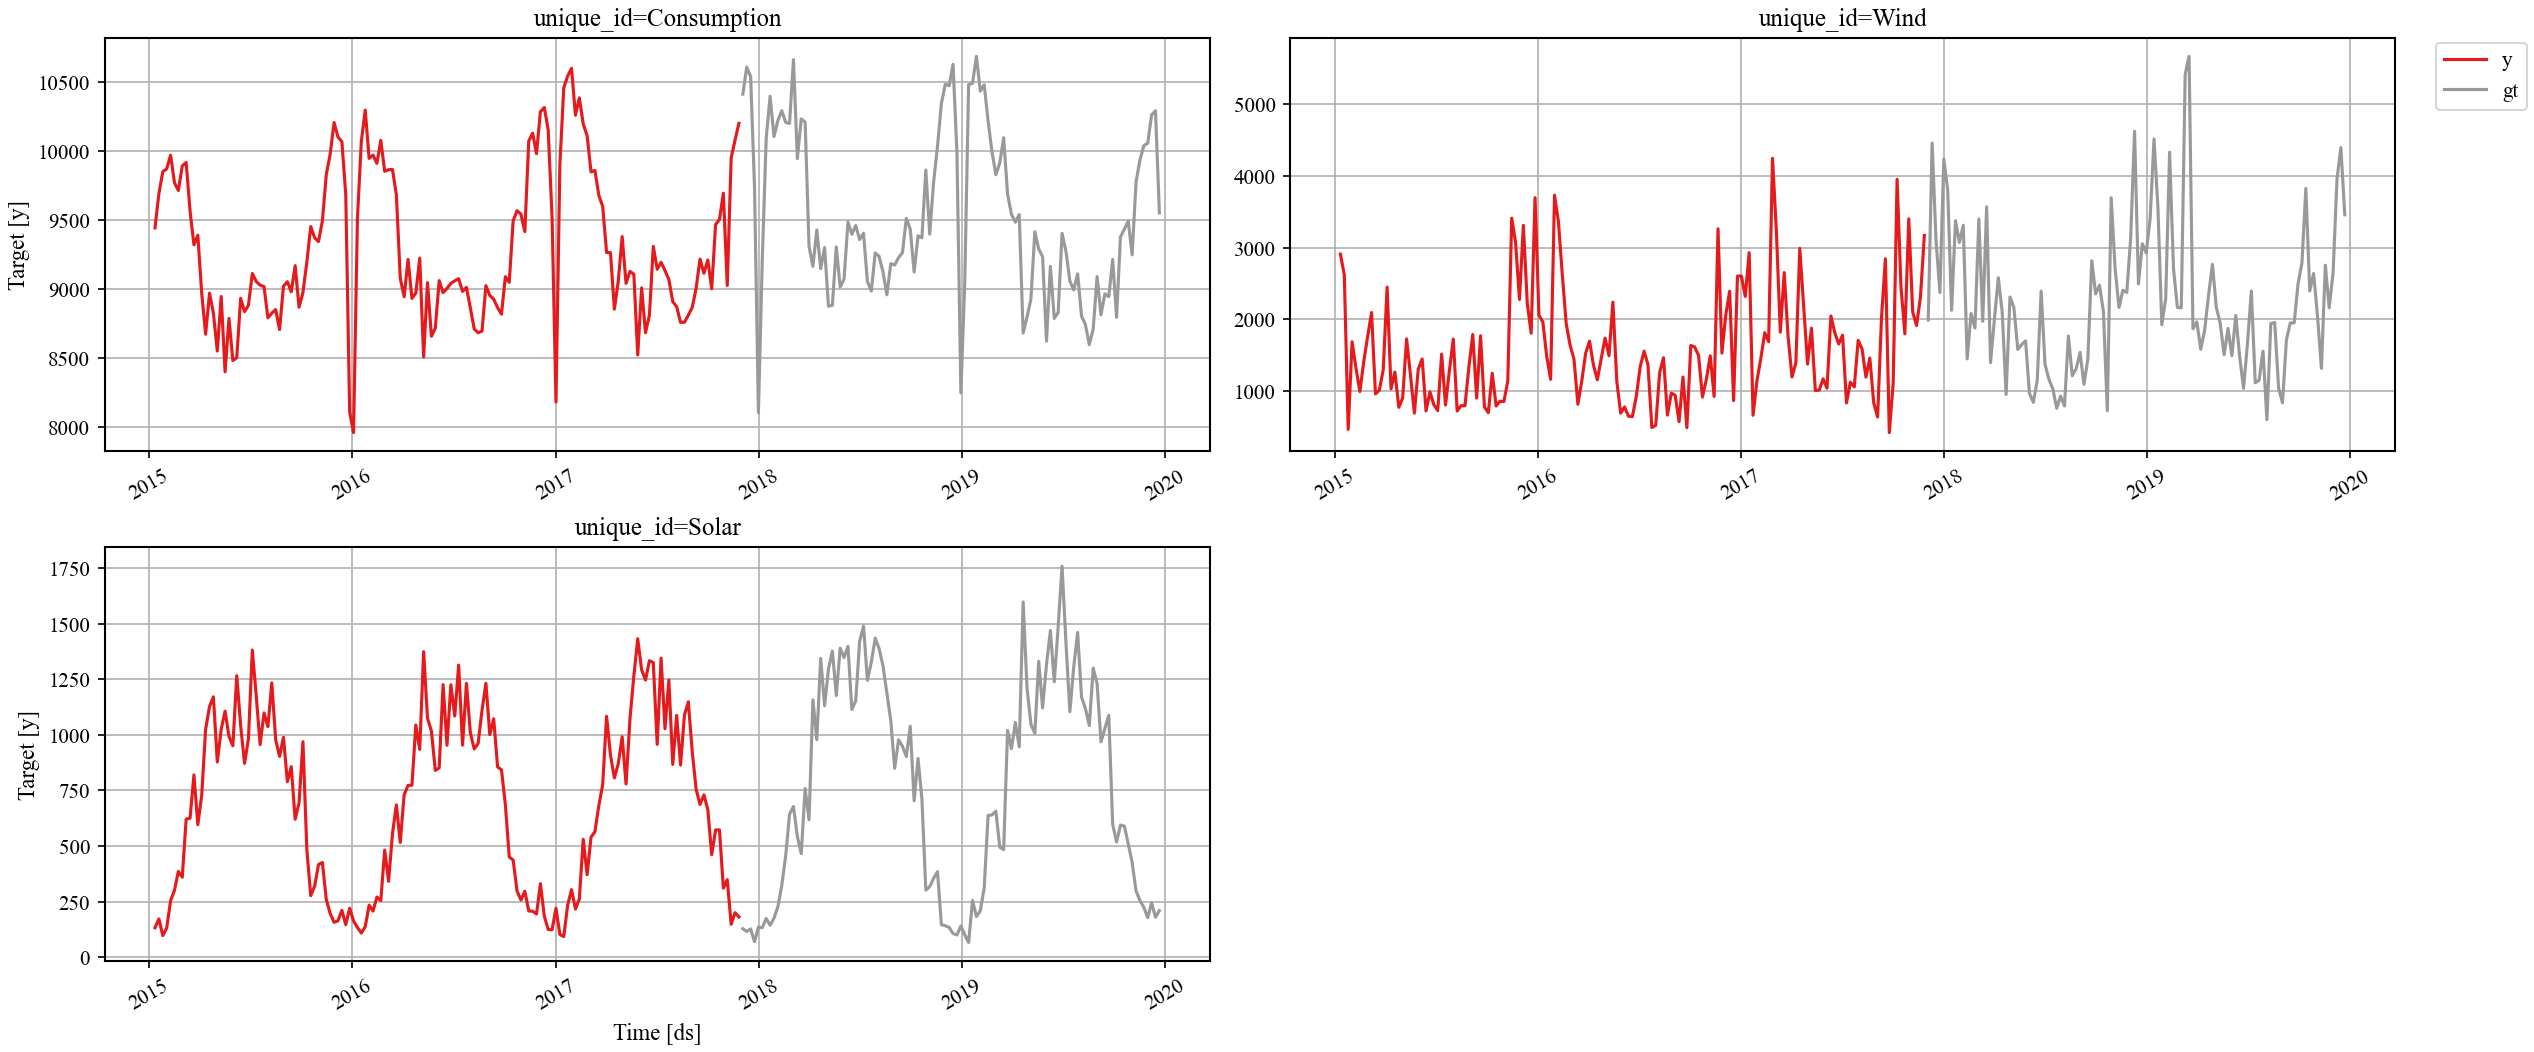

In [7]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [8]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'rmse': rmse,
    'smape': smape
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

### Backcasting

In [179]:
BH = 3*SEASON

alias = 'ARIMA'
models = [
     # AutoETS(season_length=SEASON, model='ZZA', damped = False,  ),
     ARIMA(order=(3, 1, 1),
                season_length = SEASON,
                seasonal_order = (0, 1, 1,),),
     # MSTL(season_length=[SEASON])
]
sf = StatsForecast(
    models=models,
    freq=FREQ,
)
LEVEL = [90]

In [180]:
# === BACKCAST ===
backcast_parts = []

for uid in df_train['unique_id'].unique():
    series = df_train[df_train['unique_id'] == uid].sort_values('ds')
    first_ds = series['ds'].iloc[0]

    y_rev = series['y'].iloc[::-1].values

    temp_df = pd.DataFrame({
        'unique_id': uid,
        'ds': series['ds'].values,
        'y': y_rev
    })

    fcst = sf.forecast(df=temp_df, h=BH, level=LEVEL)

    mean_bc = fcst[alias].values[::-1]
    lo_bc   = fcst[f'{alias}-lo-{LEVEL[0]}'].values[::-1]
    hi_bc   = fcst[f'{alias}-hi-{LEVEL[0]}'].values[::-1]

    backcast_dates = pd.date_range(
        end=first_ds - to_offset(FREQ),
        periods=BH,
        freq=FREQ
    )

    backcast_parts.append(pd.DataFrame({
        'unique_id': uid,
        'ds': backcast_dates,
        'y': mean_bc,
        alias: mean_bc,
        f'{alias}-lo-{LEVEL[0]}': lo_bc,
        f'{alias}-hi-{LEVEL[0]}': hi_bc
    }))

# === EXTENDED TRAIN ===
df_train_extended = (
    pd.concat(backcast_parts + [df_train], ignore_index=True)
      .sort_values(['unique_id', 'ds'])
      .reset_index(drop=True)
)


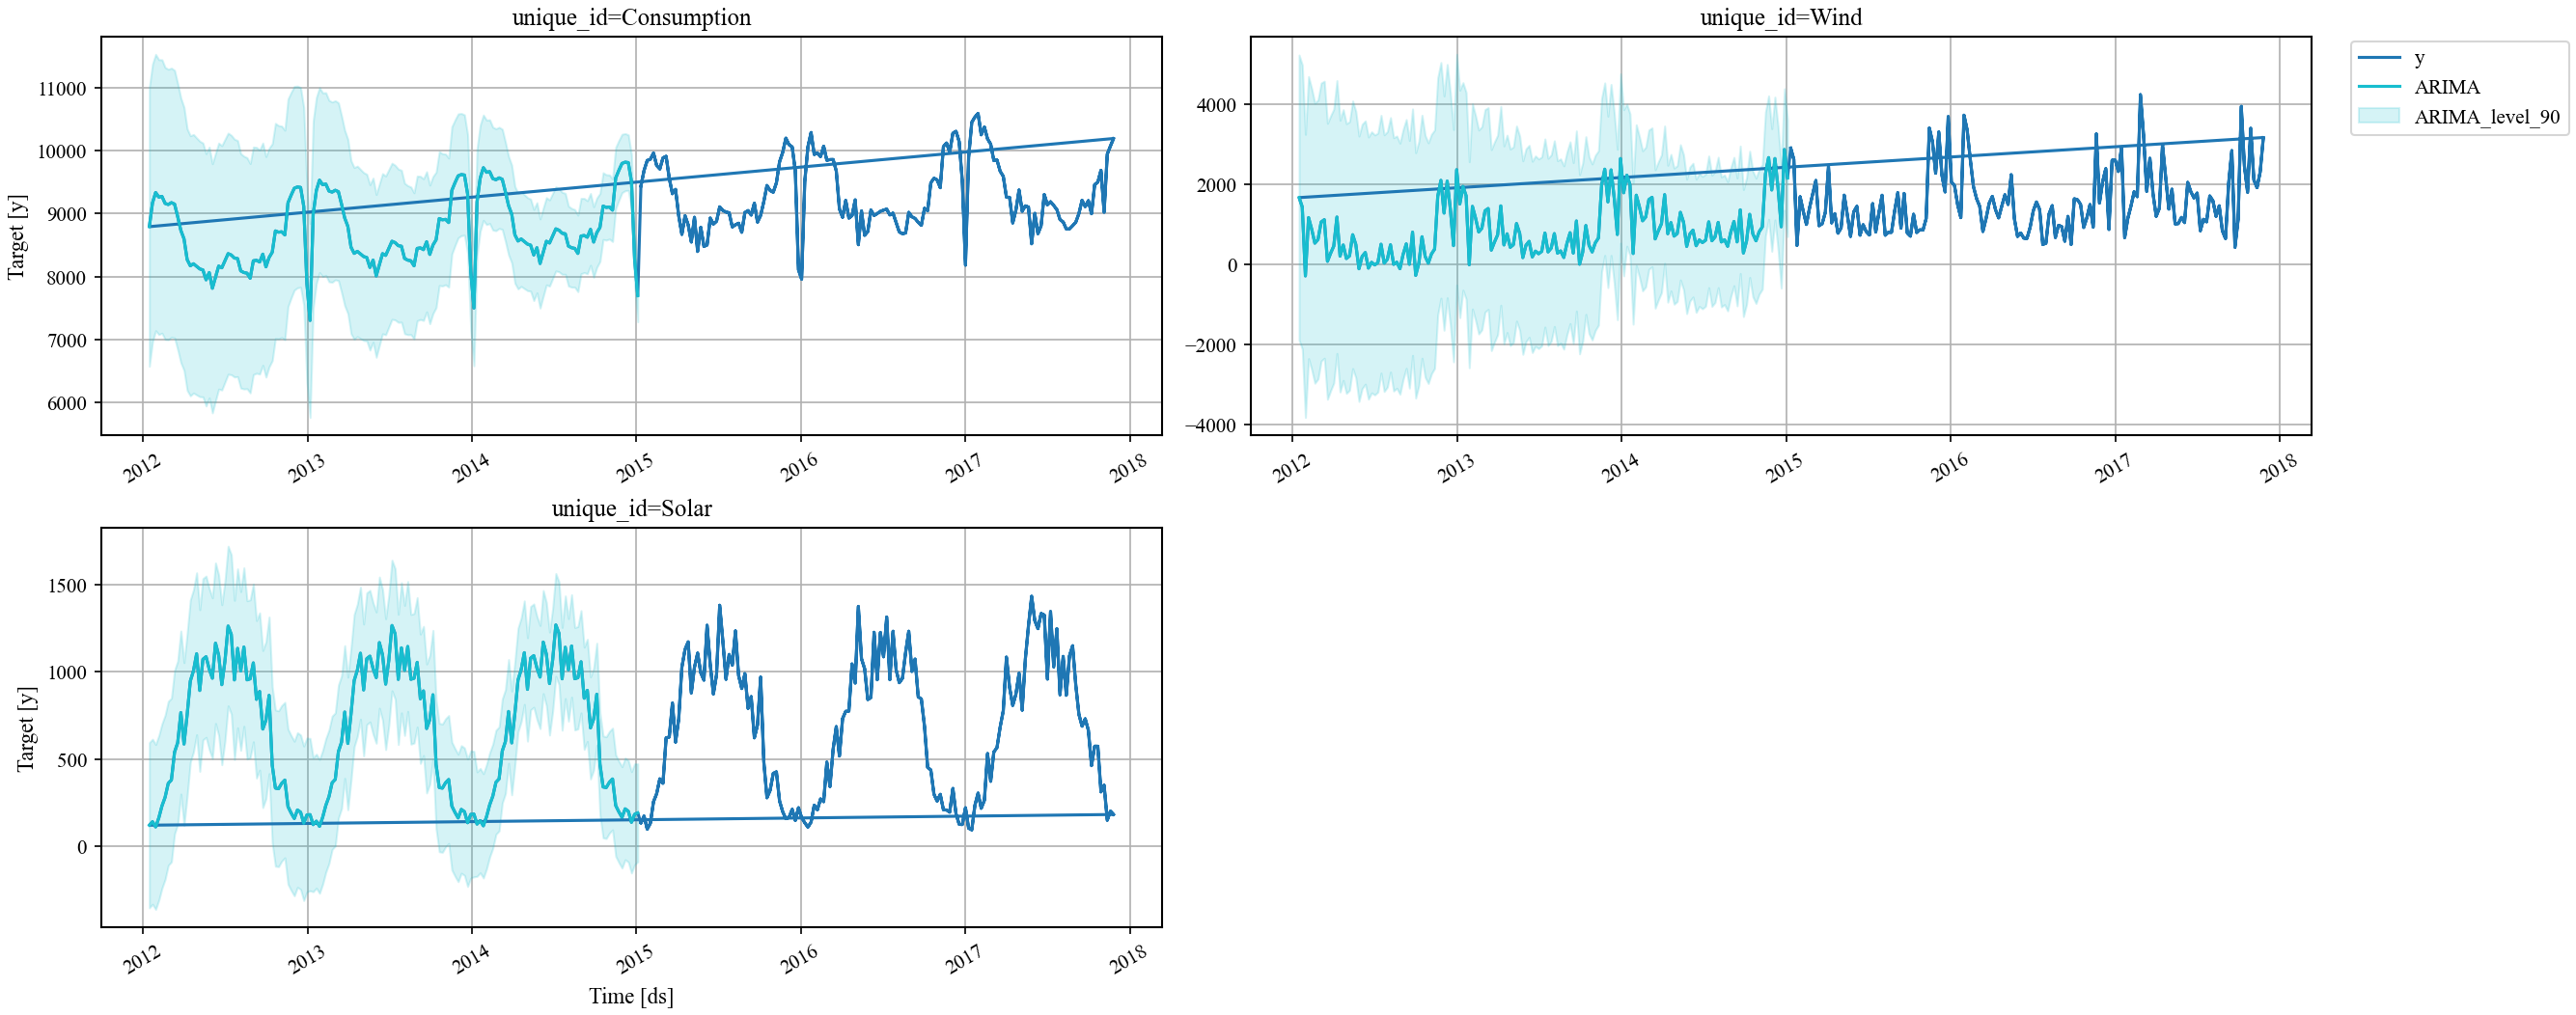

In [183]:
plot_series(df_train, forecasts_df=df_train_extended, level=LEVEL[-1:],  palette='Set1')

#### проверка на баг plot_series

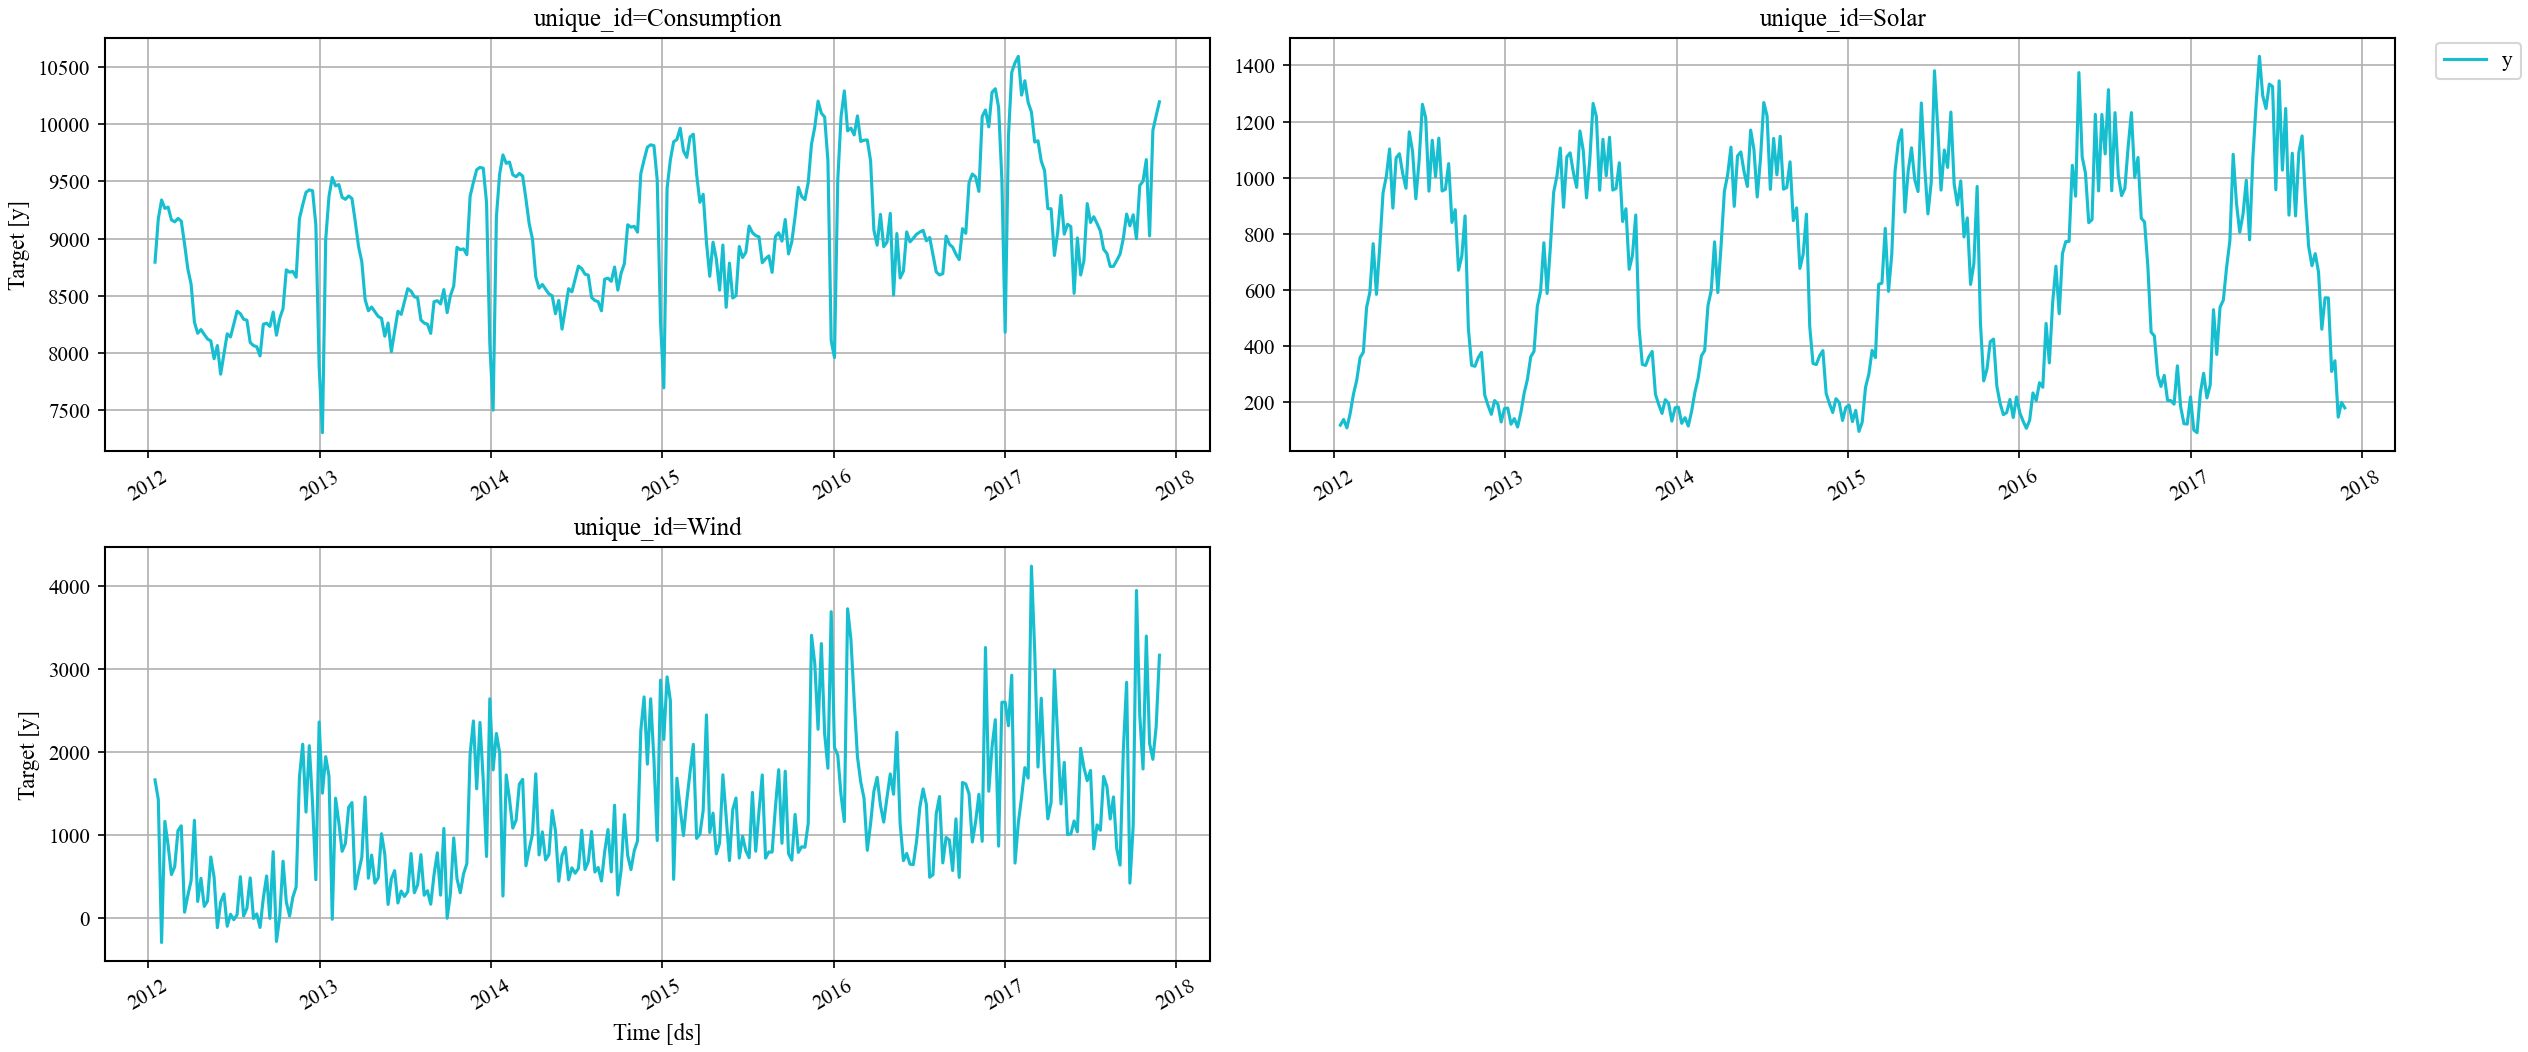

In [185]:
plot_series(df_train_extended,)

#### Сравнение методов с и без расширения

In [166]:
models = [ MSTL(season_length=[SEASON], alias = 'ETS_MSTL' ),
           MSTL(season_length=[SEASON],
               trend_forecaster=SimpleExponentialSmoothingOptimized(),
               alias = 'SES_MSTL' ),
         ]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)
aliases = [model.alias for model in models]

In [168]:
fcst_sf = sf.forecast(df=df_train_extended, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train_extended,
).pivot(
    index='metric',
    columns='unique_id',
    values=alias
)
metrics_sf_models

ETS_MSTL                            SES_MSTL              \
unique_id Consumption       Solar        Wind Consumption       Solar   
metric                                                                  
mase         1.257650    2.447960    1.584177    1.214289    2.573741   
rmse       348.285527  190.754168  977.125396  346.729084  200.313983   
smape        0.014431    0.122716    0.171879    0.013988    0.126548   

                       
unique_id        Wind  
metric                 
mase         1.511304  
rmse       981.889153  
smape        0.166598

In [169]:
fcst_sf = sf.forecast(df=df_train, h=FH)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
).pivot(
    index='metric',
    columns='unique_id',
    values=alias
)
metrics_sf_models

ETS_MSTL                            SES_MSTL              \
unique_id Consumption       Solar        Wind Consumption       Solar   
metric                                                                  
mase         1.263293    1.205407    0.911057    1.263263    1.186319   
rmse       335.003152  203.943524  969.349872  334.994069  200.526011   
smape        0.013718    0.128135    0.160751    0.013717    0.127030   

                       
unique_id        Wind  
metric                 
mase         0.922437  
rmse       955.855743  
smape        0.161919

#### Упражение 
1. провести сравнение backcasting различных методов и их виляния на метрики

Результаты показывают небольшое снижение смщения и увеличение дисперсии.

## Стресс-тесты

In [285]:
def add_structural_shift_by_iqr(
    df,
    start_date,
    shift_percent=10.0,
    strategy='linear',
    duration_weeks=26
):
    """
    Добавляет структурный сдвиг ко всем сериям.
    Поддерживает: 'linear', 'fast_saturation'
    """
    df = df.copy()
    start_date = pd.Timestamp(start_date)
    new_col = f'y_drift_{strategy}'
    df[new_col] = df['y']  # не трогаем оригинал
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        # IQR от оригинала
        q75 = sub['y'].quantile(0.75)
        q25 = sub['y'].quantile(0.25)
        iqr = q75 - q25
        shift_amount = iqr * (shift_percent / 100.0)
        
        end_date = start_date + pd.Timedelta(weeks=duration_weeks)
        transition_mask = (sub['ds'] >= start_date) & (sub['ds'] <= end_date)
        post_mask = sub['ds'] > end_date
        
        n_trans = transition_mask.sum()
        if n_trans == 0:
            continue
        
        # Генерация профиля
        if strategy == 'linear':
            t_norm = np.linspace(0, 1, n_trans)
            shift_profile = shift_amount * t_norm
            
        elif strategy == 'fast_saturation':
            t_norm = np.linspace(0, 1, n_trans)
            # Очень быстрое насыщение: 95% за 30% времени
            shift_profile = shift_amount * (1 - np.exp(-8 * t_norm))
            
        else:
            raise ValueError("strategy must be 'linear' or 'fast_saturation'")
        
        # Применяем
        sub.loc[transition_mask, new_col] += shift_profile
        if post_mask.any():
            sub.loc[post_mask, new_col] += shift_amount
        
        df.loc[mask, new_col] = sub[new_col].values
    
    return df

# === Применение ===
df_result = df_train.copy()

df_result = add_structural_shift_by_iqr(
    df_result, 
    start_date='2016-01-01', 
    shift_percent=100, 
    strategy='linear', 
    duration_weeks=FH
)

df_result = add_structural_shift_by_iqr(
    df_result, 
    start_date='2016-01-01', 
    shift_percent=100, 
    strategy='fast_saturation', 
    duration_weeks=FH
)

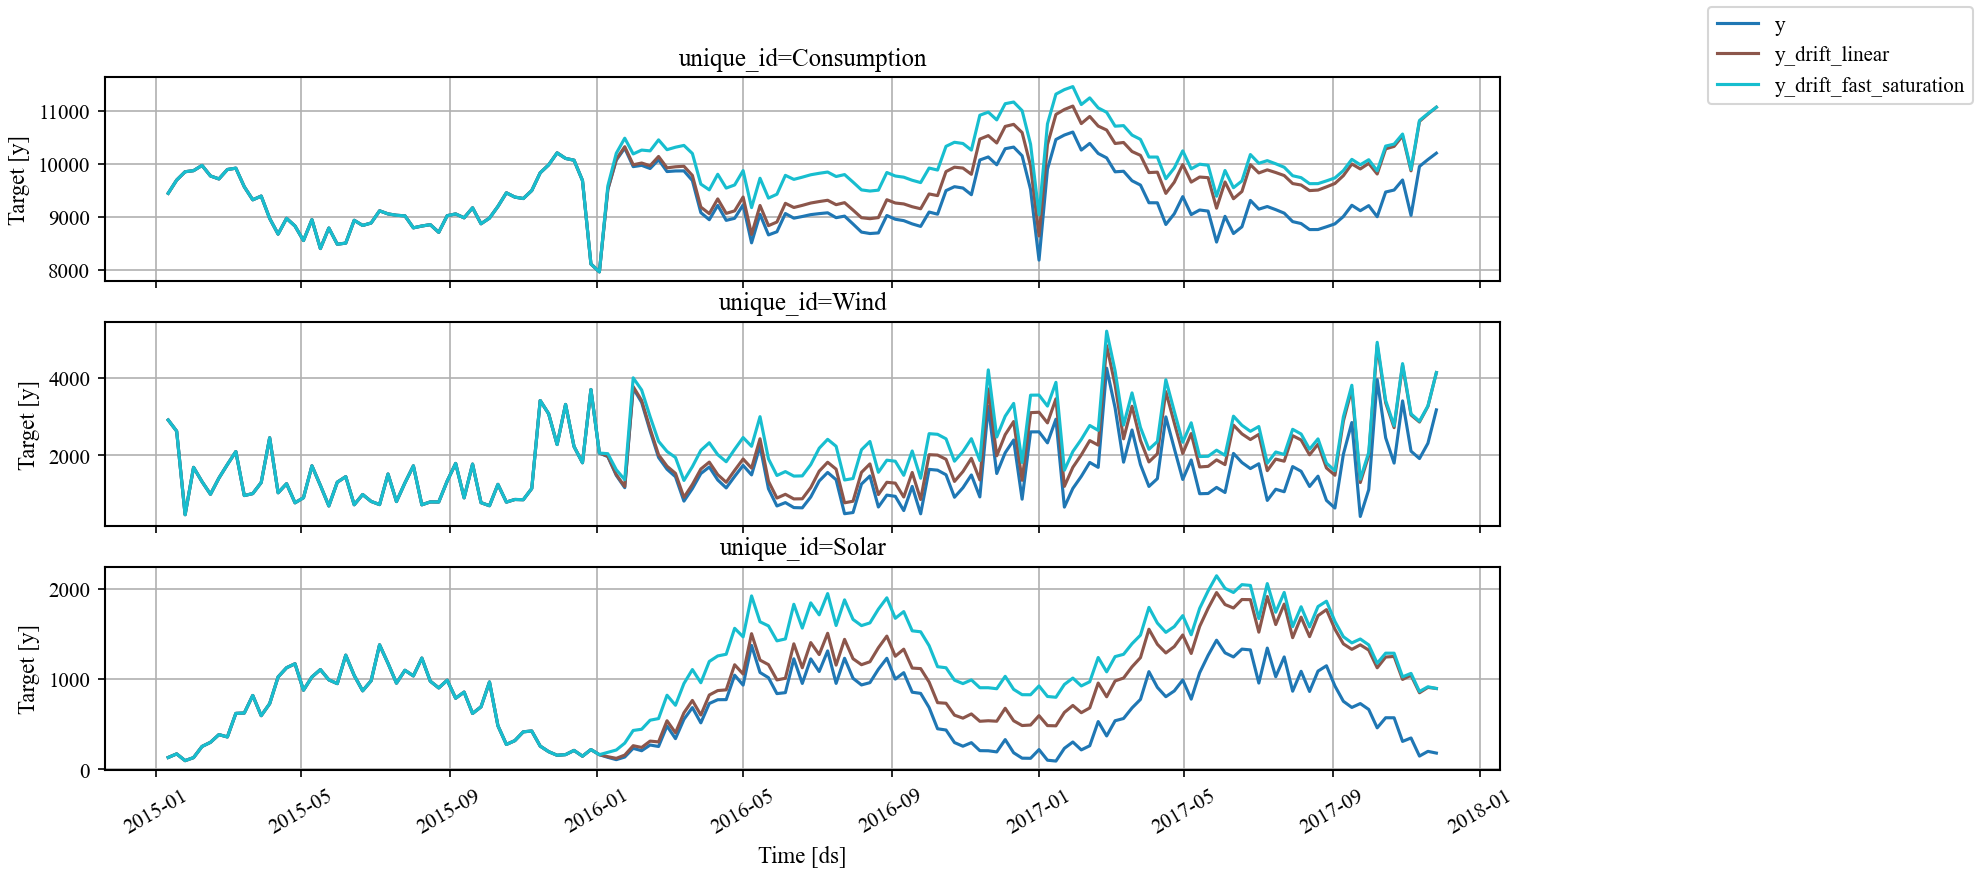

In [286]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [322]:
def add_addtitive_shock(df, shock_date='2015-03-01', shock_strength=1.5, recovery_weeks=12):
    df = df.copy()
    df['y_hybrid_shock'] = df['y'].copy()
    shock_date = pd.Timestamp(shock_date)
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        if sub['ds'].max() < shock_date:
            continue
        
        shock_row = sub[sub['ds'] >= shock_date].index[0]
        idx = list(sub.index).index(shock_row)
        
        n = len(sub)
        rec_n = min(recovery_weeks, n - idx)
        if rec_n <= 0:
            continue
        
        # IQR для адаптивного размера
        q75 = sub['y'].quantile(0.75)
        q25 = sub['y'].quantile(0.25)
        iqr = q75 - q25
        shock_amount = iqr * shock_strength
        
        original_y = sub['y'].values
        shocked_y = original_y.copy()
        
        # Прокол: резкое падение
        shocked_y[idx] -= shock_amount
        
        # Экспоненциальное восстановление
        for i in range(1, rec_n):
            t = i / rec_n
            shocked_y[idx + i] = shocked_y[idx + i - 1] + (original_y[idx + i] - shocked_y[idx + i - 1]) * (1 - np.exp(-3 * t))
        
        # После восстановления — остаёмся на оригинале
        if idx + rec_n < n:
            shocked_y[idx + rec_n:] = original_y[idx + rec_n:]
        
        sub['y_hybrid_shock'] = shocked_y
        df.loc[mask, 'y_hybrid_shock'] = sub['y_hybrid_shock'].values
    
    return df

In [323]:
# Применение
df_result = add_addtitive_shock(
    df_train,
    shock_date='2015-03-01',
    shock_strength=1.5,   # 1.5 * IQR — сильный шок
    recovery_weeks=12
)

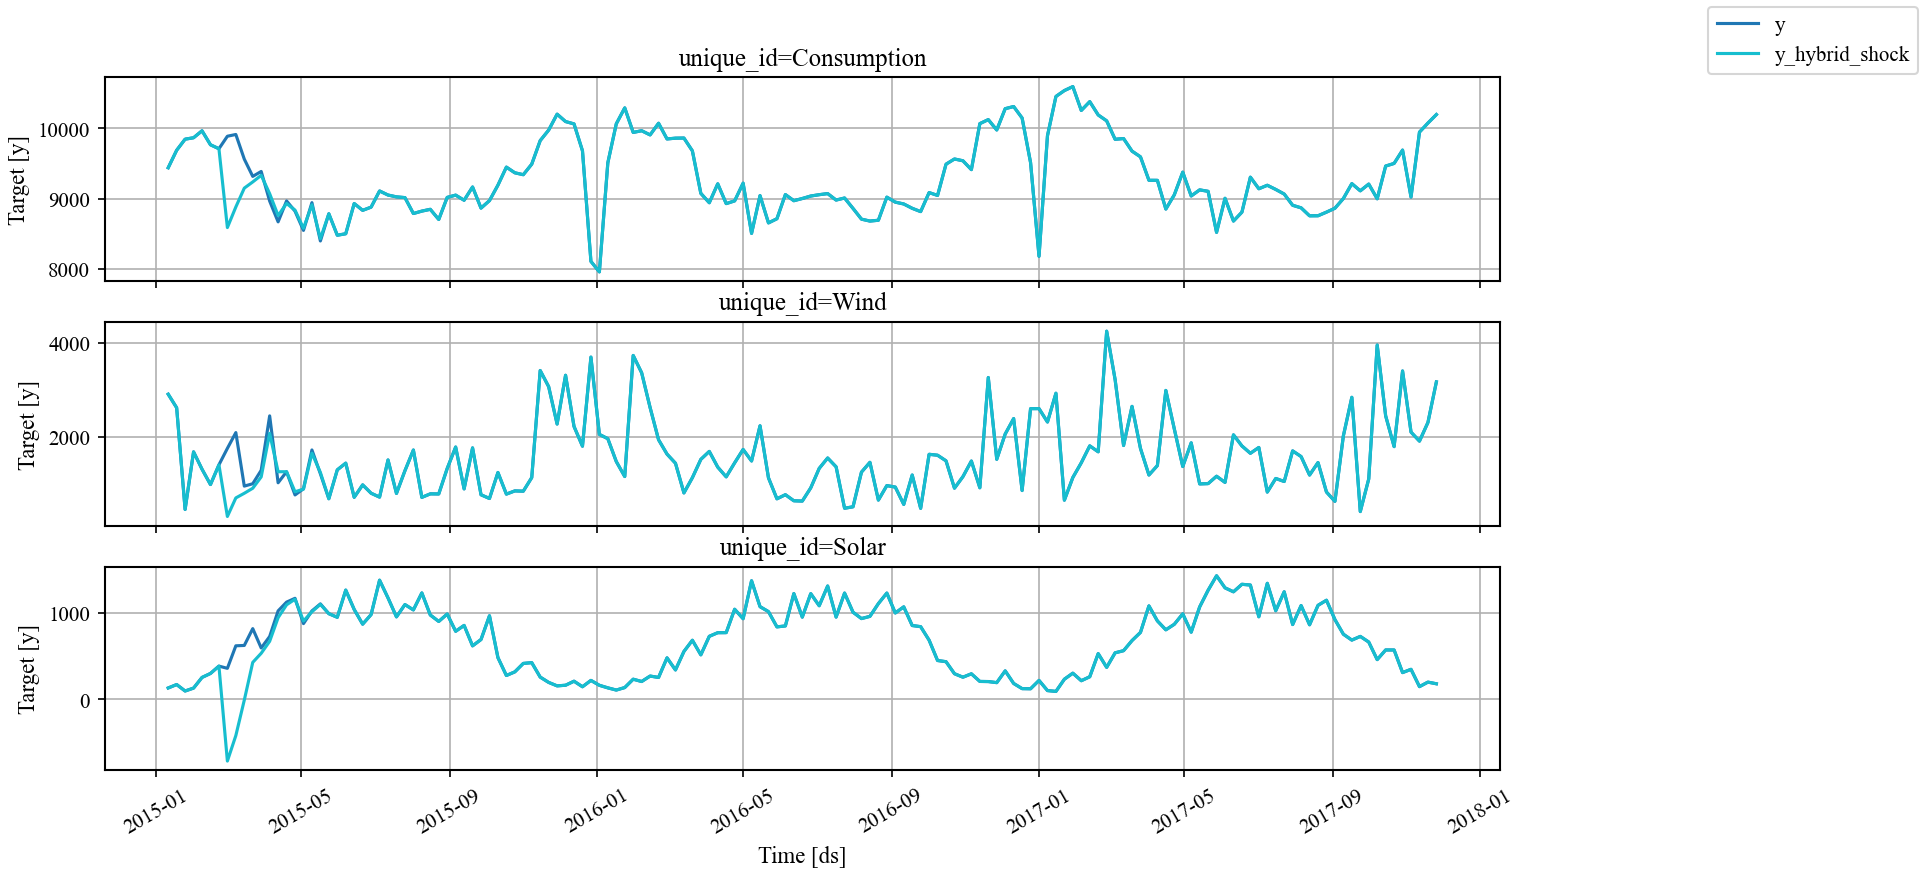

In [324]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

 1. Сезонный дисбаланс
Увеличение/уменьшение амплитуды сезонности в определённые месяцы (например, летом потребление падает сильнее).
→ Тестирует: устойчивость к изменению сезонного паттерна.

📉 2. Трендовый разрыв (trend break)
Резкое изменение наклона тренда (рост → стагнация или падение).
→ Тестирует: способность модели перестраивать тренд.

🌀 3. Фазовый сдвиг сезонности
Сдвиг пиков/провалов на ±N недель (например, праздники перенесены).
→ Тестирует: чувствительность к фазе цикла.

📡 4. Интервалы потери данных
Искусственные пропуски (например, каждые 4 недели — 2 недели NaN), заполненные линейной интерполяцией.
→ Тестирует: устойчивость к плохой связи/деградации датчиков.

📈 5. Локальный всплеск волатильности
Кратковременное увеличение шума (σ × 3–5) на 2–4 недели.
→ Тестирует: реакцию на выбросы и шум.

⚖️ 6. Асимметричный шок
Падение на 30% за 1 неделю, восстановление за 8 недель (или наоборот).
→ Тестирует: способность модели различать скорость изменений.

🔄 7. Циклический дрейф частоты
Постепенное изменение длины сезона (например, 52 → 50 недель за 2 года).
→ Тестирует: адаптацию к изменению периодичности.

🌡️ 8. Экзогенный стресс по аналогии
Добавление "внешнего фактора": например, имитация температурного шока (резкий холод → рост demand).
→ Тестирует: работу с экзогенными переменными.

📉 9. Деградация сигнала
Постепенное снижение отношения сигнал/шум (SNR) — полезно для IoT/промышленных датчиков.
→ Тестирует: пределы работоспособности при шуме.

In [335]:
import pandas as pd
import numpy as np

def add_seasonal_imbalance_by_quantile(
    df,
    target_months=[6,7,8],     # летние месяцы
    imbalance_percent=30.0,     # % от (q95 - q5) для усиления/ослабления
    direction='reduce',         # 'reduce' = ослабить, 'amplify' = усилить
    start_year=2015
):
    """
    Добавляет сезонный дисбаланс:
    - в указанные месяцы изменяет амплитуду сезонности на % от (q95 - q5)
    - direction: 'reduce' → снижает, 'amplify' → усиливает
    """
    df = df.copy()
    df['y_seasonal_imbalance'] = df['y'].copy()
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        # Рассчитываем q5 и q95 по всему ряду (или по предшествующему периоду)
        q5 = sub['y'].quantile(0.05)
        q95 = sub['y'].quantile(0.95)
        amplitude = q95 - q5
        
        # Определяем месяц и год
        month_mask = sub['ds'].dt.month.isin(target_months)
        year_mask = sub['ds'].dt.year >= start_year
        apply_mask = month_mask & year_mask
        
        if not apply_mask.any():
            continue
        
        # Сдвигаем значения
        shift_amount = amplitude * (imbalance_percent / 100.0)
        
        if direction == 'reduce':
            # Ослабляем сезонность: приближаем к среднему
            mean_level = (q5 + q95) / 2
            sub.loc[apply_mask, 'y_seasonal_imbalance'] = (
                sub.loc[apply_mask, 'y_seasonal_imbalance'] +
                (mean_level - sub.loc[apply_mask, 'y_seasonal_imbalance']) * (shift_amount / amplitude)
            )
        elif direction == 'amplify':
            # Усиливаем сезонность: отталкиваем от среднего
            mean_level = (q5 + q95) / 2
            sub.loc[apply_mask, 'y_seasonal_imbalance'] = (
                sub.loc[apply_mask, 'y_seasonal_imbalance'] +
                (sub.loc[apply_mask, 'y_seasonal_imbalance'] - mean_level) * (shift_amount / amplitude)
            )
        
        df.loc[mask, 'y_seasonal_imbalance'] = sub['y_seasonal_imbalance'].values
    
    return df

# Применение
df_result = add_seasonal_imbalance_by_quantile(
    df_train,
    target_months=[6,7,8],
    imbalance_percent=80.0,   # 40% от (q95-q5)
    direction='amplify',       # ослабить летний спад
    start_year=2015
)

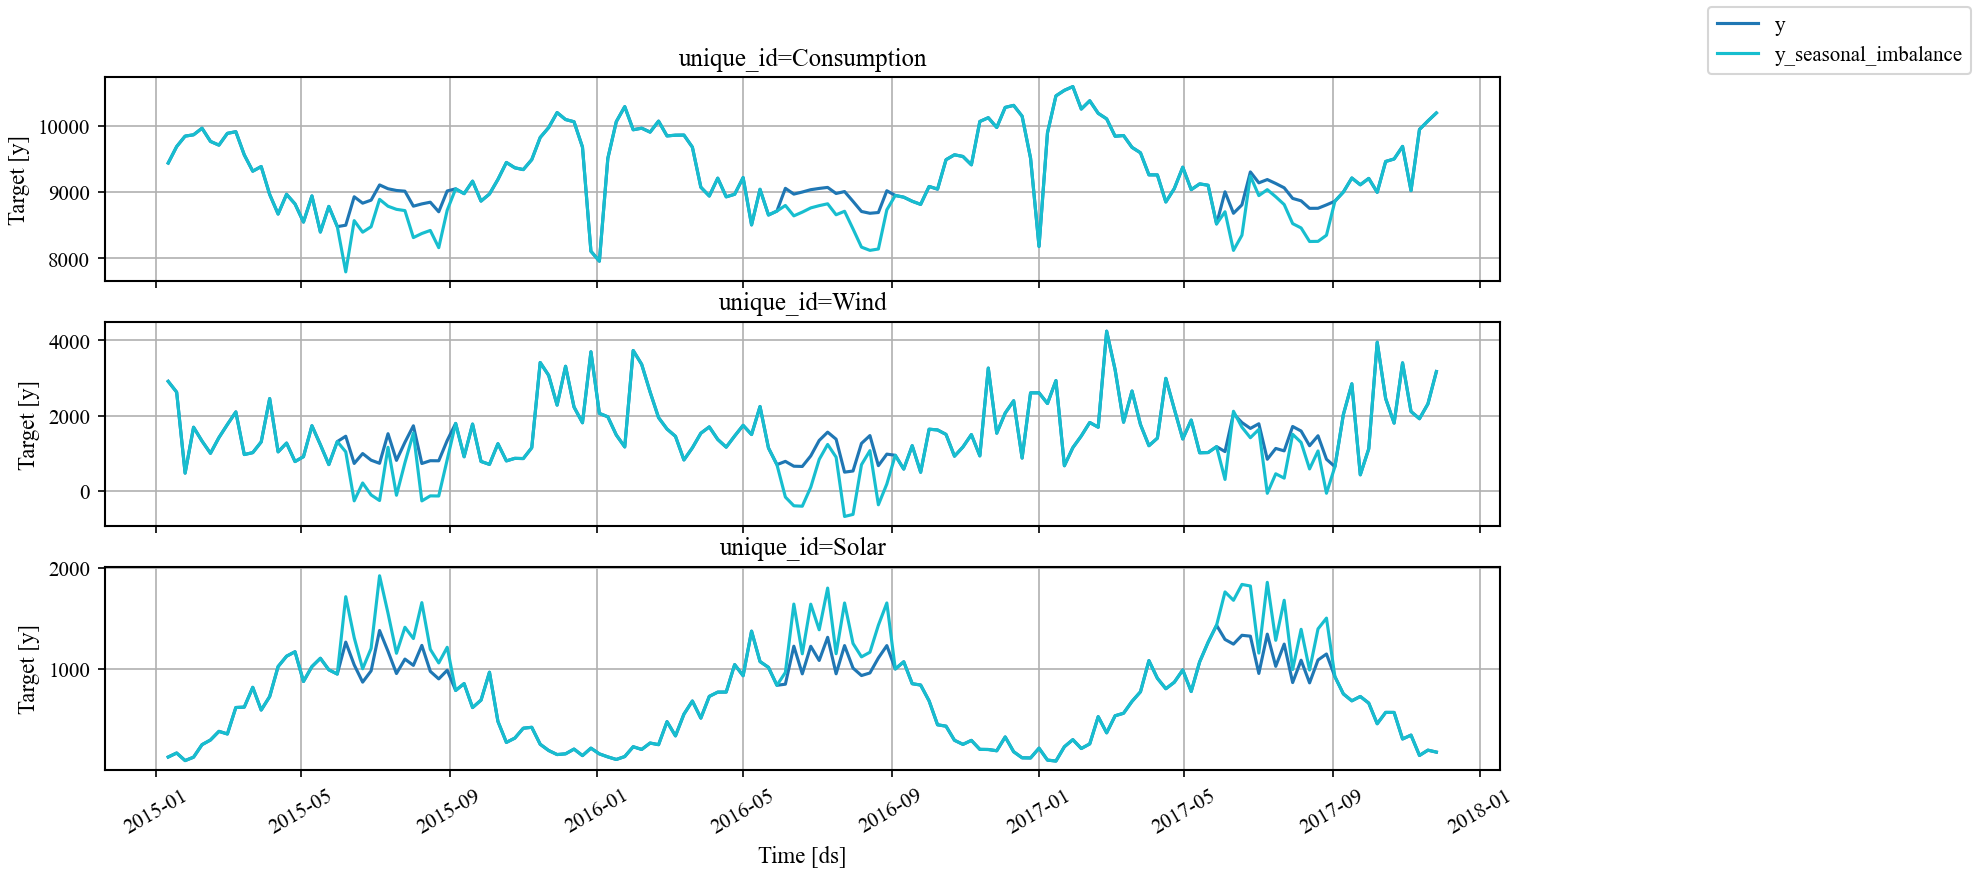

In [336]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [337]:
def add_local_volatility_spike(
    df,
    spike_start='2015-06-01',
    duration_weeks=4,
    noise_percent=50.0  # % от (q95 - q5)
):
    """
    Добавляет локальный всплеск шума:
    - в период [spike_start, spike_start + duration_weeks]
    - шум ~ N(0, sigma), где sigma = (q95 - q5) * (noise_percent / 100)
    """
    df = df.copy()
    df['y_volatility_spike'] = df['y'].copy()
    start = pd.Timestamp(spike_start)
    end = start + pd.Timedelta(weeks=duration_weeks)
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        # Квантили по всей серии
        q5 = sub['y'].quantile(0.05)
        q95 = sub['y'].quantile(0.95)
        amplitude = q95 - q5
        
        # Маска периода всплеска
        spike_mask = (sub['ds'] >= start) & (sub['ds'] <= end)
        
        if not spike_mask.any():
            continue
        
        # Стандартное отклонение шума
        sigma = amplitude * (noise_percent / 100.0)
        
        # Генерируем шум
        np.random.seed(42)  # для воспроизводимости
        noise = np.random.normal(0, sigma, spike_mask.sum())
        
        # Добавляем шум
        sub.loc[spike_mask, 'y_volatility_spike'] += noise
        
        df.loc[mask, 'y_volatility_spike'] = sub['y_volatility_spike'].values
    
    return df

In [340]:
df_result = add_local_volatility_spike(
    df_train,
    spike_start='2015-06-01',
    duration_weeks=14,
    noise_percent=60.0  # шум = 60% от (q95 - q5)
)

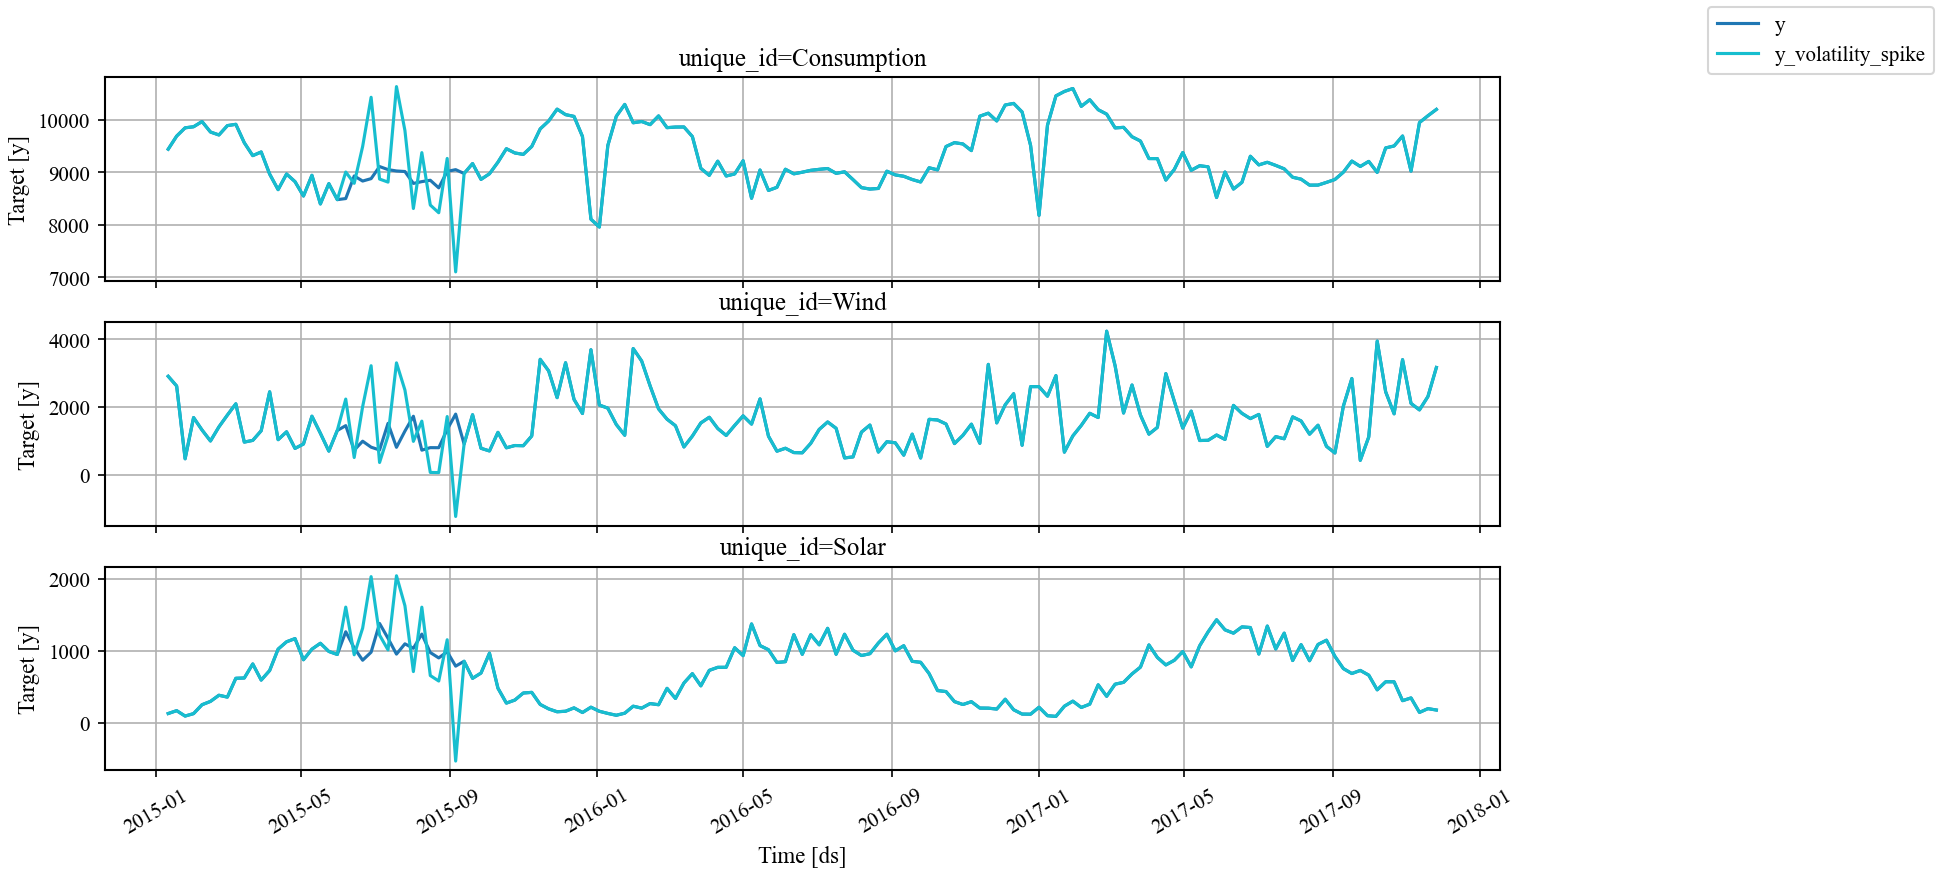

In [341]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [342]:
def add_asymmetric_shock(
    df,
    shock_start='2015-03-01',
    drop_percent=40.0,      # % от (q95 - q5)
    recovery_weeks=8
):
    """
    Добавляет асимметричный шок:
    - резкое падение за 1 неделю,
    - медленное восстановление за recovery_weeks.
    """
    df = df.copy()
    df['y_asymmetric_shock'] = df['y'].copy()
    start = pd.Timestamp(shock_start)
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        if sub['ds'].max() < start:
            continue
        
        # Находим первую дату >= shock_start
        shock_idx = sub[sub['ds'] >= start].index[0]
        idx_pos = list(sub.index).index(shock_idx)
        
        n = len(sub)
        rec_n = min(recovery_weeks, n - idx_pos - 1)
        if rec_n <= 0:
            continue
        
        # Масштаб по квантилям
        q5 = sub['y'].quantile(0.05)
        q95 = sub['y'].quantile(0.95)
        amplitude = q95 - q5
        drop_amount = amplitude * (drop_percent / 100.0)
        
        # Копируем исходные значения
        shocked_y = sub['y'].values.copy()
        
        # 1. Резкое падение (1 неделя)
        shocked_y[idx_pos] -= drop_amount
        
        # 2. Линейное восстановление за recovery_weeks
        for i in range(1, rec_n + 1):
            shocked_y[idx_pos + i] = shocked_y[idx_pos] + drop_amount * (i / (rec_n + 1))
        
        # После восстановления — возвращаемся к оригиналу
        if idx_pos + rec_n + 1 < n:
            shocked_y[idx_pos + rec_n + 1:] = sub['y'].values[idx_pos + rec_n + 1:]
        
        sub['y_asymmetric_shock'] = shocked_y
        df.loc[mask, 'y_asymmetric_shock'] = sub['y_asymmetric_shock'].values
    
    return df

In [343]:
df_result = add_asymmetric_shock(
    df_train,
    shock_start='2015-03-01',
    drop_percent=50.0,      # падение = 50% от (q95 - q5)
    recovery_weeks=8        # восстановление за 8 недель
)

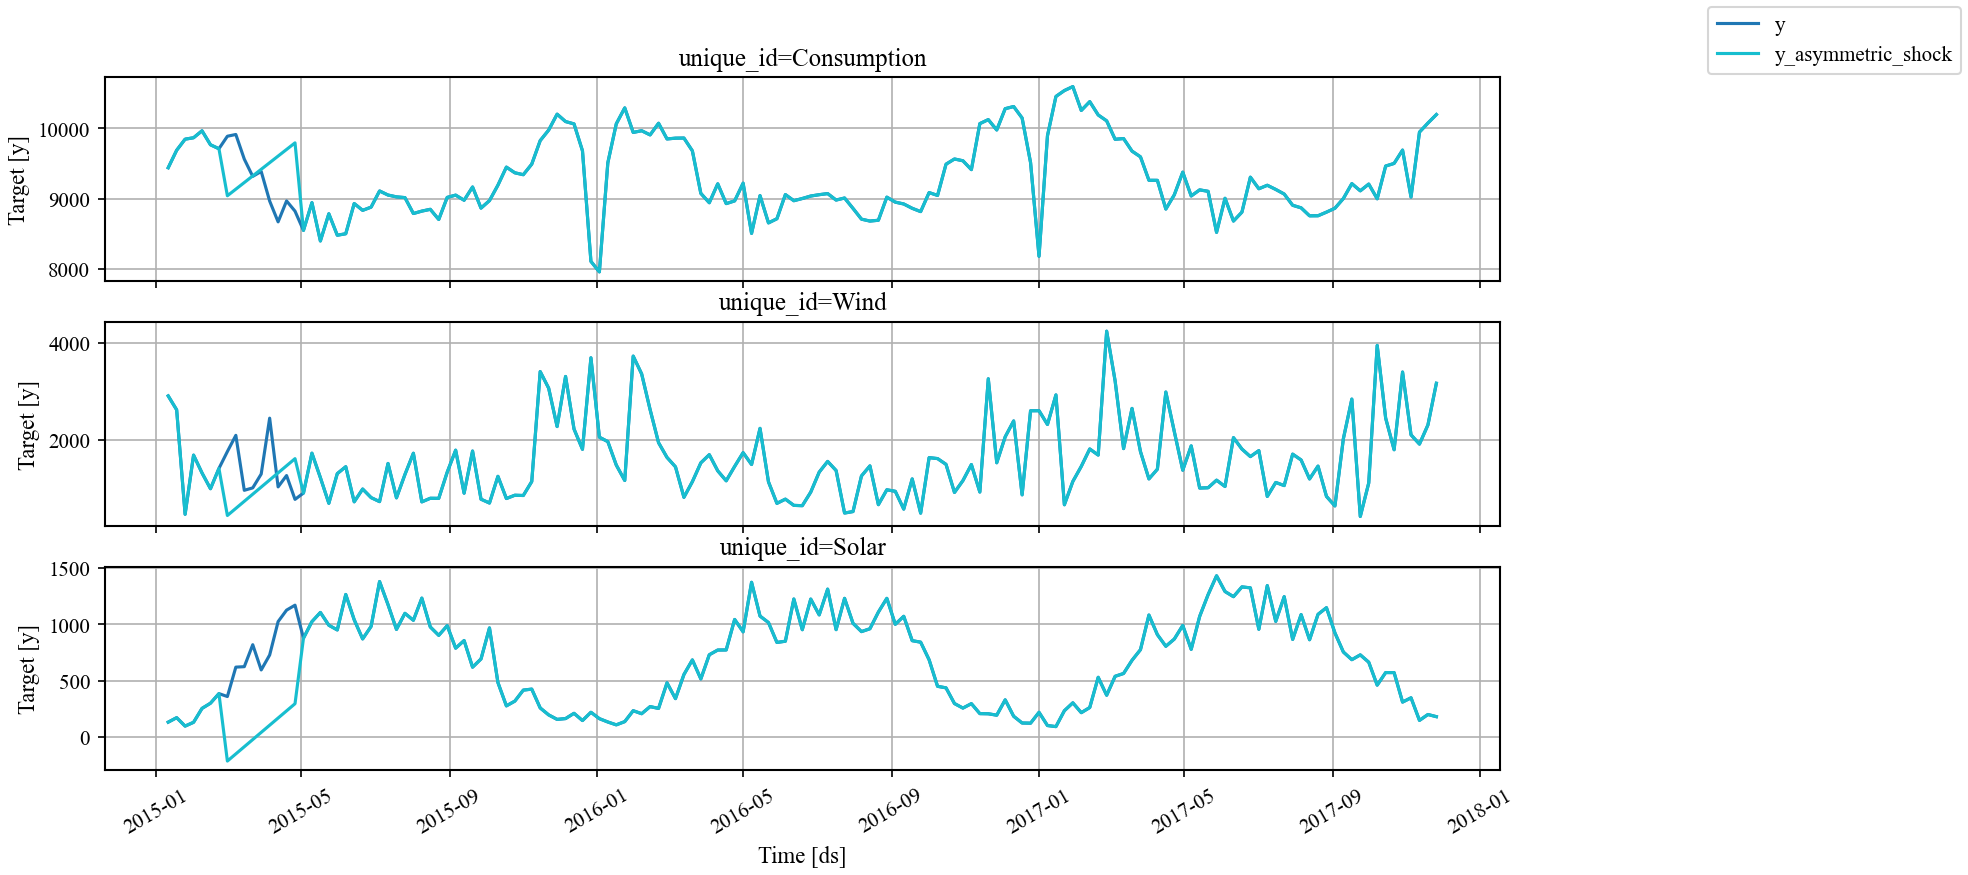

In [344]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [345]:
def add_signal_degradation(
    df,
    degradation_start='2015-01-01',
    duration_weeks=52,      # за сколько недель шум вырастет до уровня сигнала
    final_snr_ratio=0.5     # финальное отношение шум/сигнал (0.5 = шум = 50% от амплитуды)
):
    """
    Постепенно деградирует сигнал: увеличивает шум от 0 до final_snr_ratio * (q95 - q5).
    """
    df = df.copy()
    df['y_degraded'] = df['y'].copy()
    start = pd.Timestamp(degradation_start)
    end = start + pd.Timedelta(weeks=duration_weeks)
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        # Квантили по всей серии
        q5 = sub['y'].quantile(0.05)
        q95 = sub['y'].quantile(0.95)
        amplitude = q95 - q5
        
        # Маска периода деградации
        degrade_mask = (sub['ds'] >= start) & (sub['ds'] <= end)
        post_mask = sub['ds'] > end
        
        if not degrade_mask.any():
            continue
        
        # Индексы для линейного нарастания шума
        degrade_idx = sub[degrade_mask].index
        n_degrade = len(degrade_idx)
        
        # Финальное стандартное отклонение шума
        final_sigma = amplitude * final_snr_ratio
        
        # Генерируем шум с нарастающей интенсивностью
        np.random.seed(42)
        for i, idx in enumerate(degrade_idx):
            t = i / max(n_degrade - 1, 1)  # от 0 до 1
            sigma = final_sigma * t
            noise = np.random.normal(0, sigma)
            sub.loc[idx, 'y_degraded'] += noise
        
        # После периода — постоянный высокий шум
        if post_mask.any():
            np.random.seed(43)
            n_post = post_mask.sum()
            noise_post = np.random.normal(0, final_sigma, n_post)
            sub.loc[post_mask, 'y_degraded'] += noise_post
        
        df.loc[mask, 'y_degraded'] = sub['y_degraded'].values
    
    return df

In [351]:
df_result = add_signal_degradation(
    df_train,
    degradation_start='2015-01-01',
    duration_weeks=52,      # год деградации
    final_snr_ratio=0.1     # шум = 60% от амплитуды сигнала
)

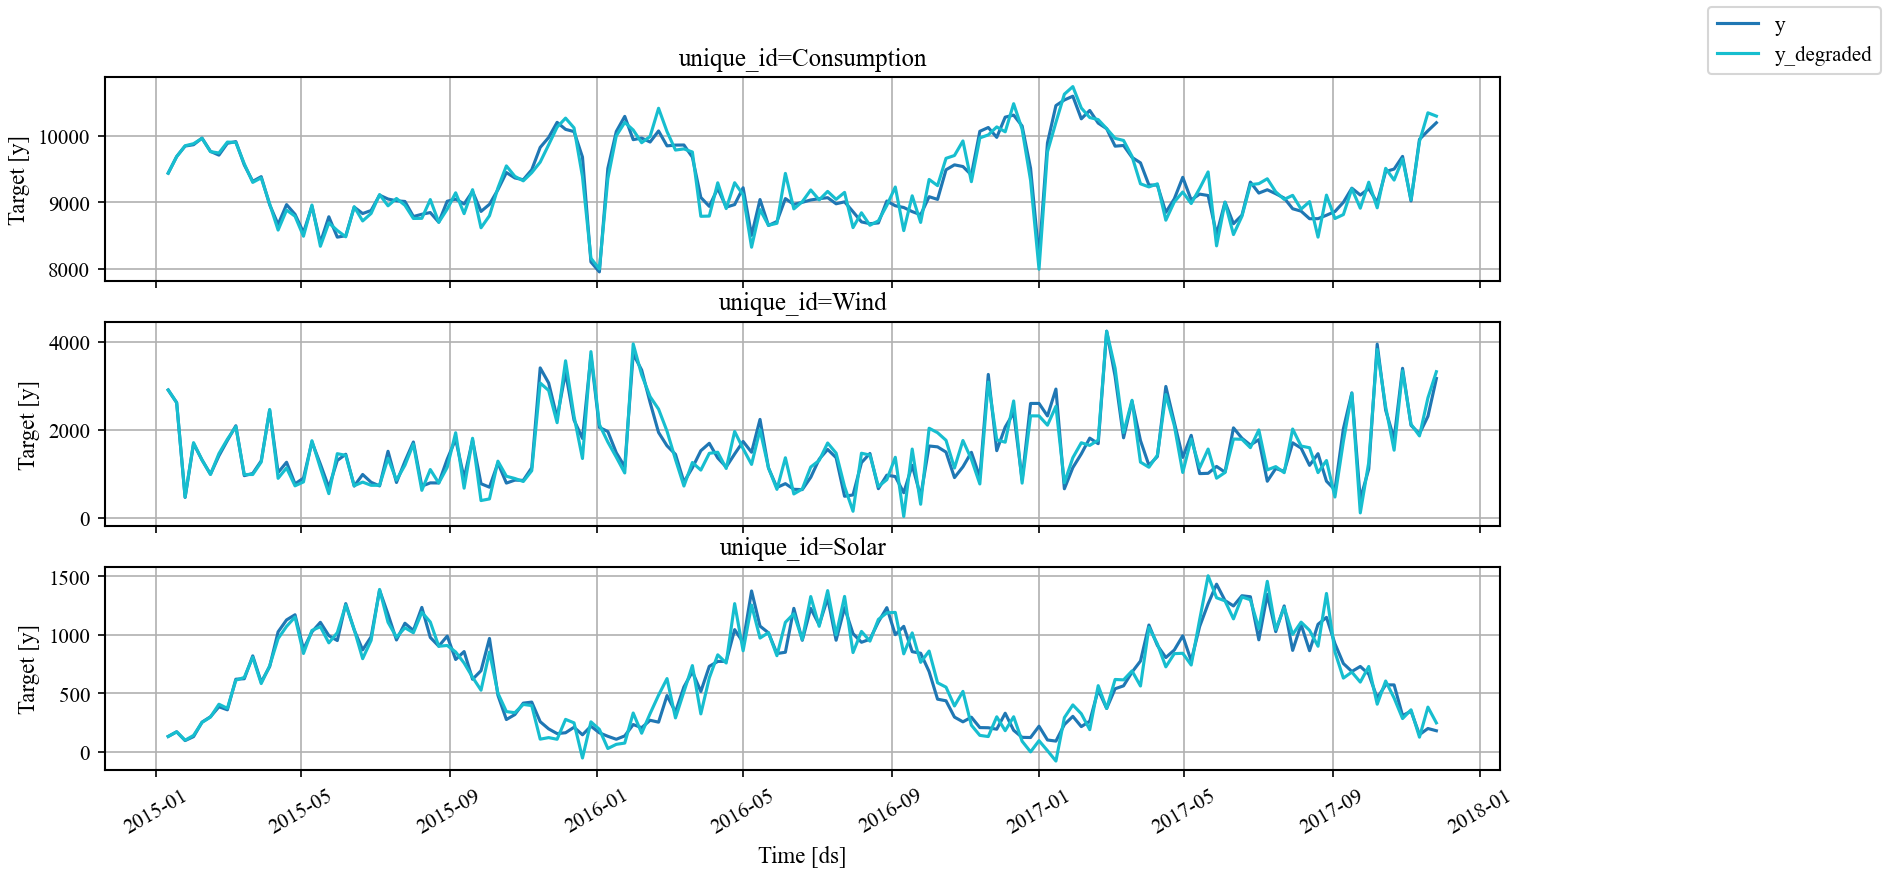

In [352]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [360]:
def add_seasonal_phase_shift(
    df,
    shift_weeks=4,
    season_length=52,
    start_year=2015,
    duration_years=1  # ← добавлено!
):
    """
    Сдвигает фазу сезонности на shift_weeks недель
    в течение duration_years лет, начиная с start_year.
    """
    df = df.copy()
    df['y_phase_shift'] = df['y'].copy()
    
    end_year = start_year + duration_years - 1  # включительно
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        # Применяем только в [start_year, end_year]
        apply_mask = (sub['ds'].dt.year >= start_year) & (sub['ds'].dt.year <= end_year)
        if not apply_mask.any():
            continue
        
        sub['year'] = sub['ds'].dt.year
        sub['week_of_year'] = sub['ds'].dt.isocalendar().week
        sub['week_of_year'] = sub['week_of_year'].clip(1, season_length)
        
        shifted_y = sub['y'].values.copy()
        idx_list = list(sub.index)
        
        # Группируем по году в диапазоне
        for year in range(start_year, end_year + 1):
            year_mask = (sub['year'] == year)
            if not year_mask.any():
                continue
            
            year_data = sub[year_mask]
            idxs = year_data.index
            values = year_data['y'].values
            
            if len(values) < season_length // 2:
                continue
            
            # Циклический сдвиг
            shifted_values = np.roll(values, -shift_weeks)
            
            # Обновляем
            for i, idx in enumerate(idxs):
                pos = idx_list.index(idx)
                shifted_y[pos] = shifted_values[i]
        
        sub['y_phase_shift'] = shifted_y
        df.loc[mask, 'y_phase_shift'] = sub['y_phase_shift'].values
    
    return df

In [361]:
df_result = add_seasonal_phase_shift(
    df_train,
    shift_weeks=3,
    season_length=52,
    start_year=2015,
    duration_years=1  # ← только 2015
)

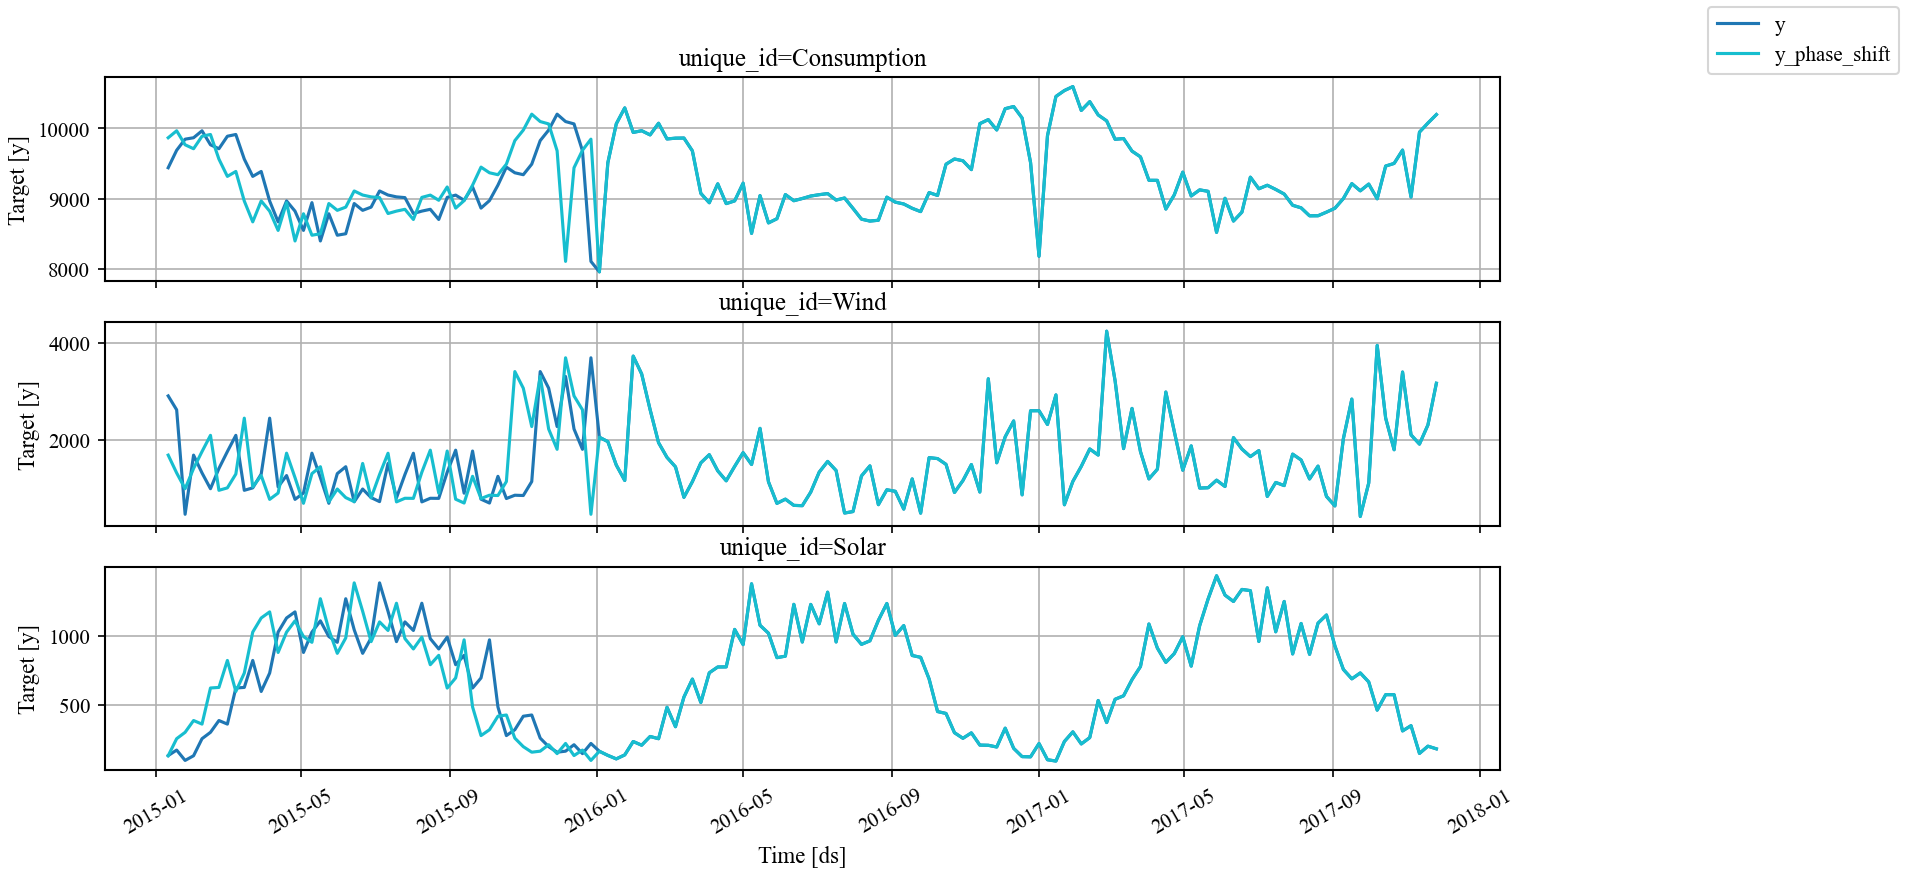

In [362]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [363]:
def add_trend_break(
    df,
    break_date='2015-01-01',
    trend_change=-0.02,      # изменение наклона: -0.02 = -2% в неделю
    duration_years=2,        # сколько лет длится новый тренд
    return_to_original=True  # после duration — вернуться к оригиналу?
):
    """
    Добавляет трендовый разрыв:
    - trend_change: изменение наклона (в единицах y / неделя)
    - если trend_change < 0 → падение, >0 → ускорение
    """
    df = df.copy()
    df['y_trend_break'] = df['y'].copy()
    break_date = pd.Timestamp(break_date)
    end_date = break_date + pd.DateOffset(years=duration_years)
    
    for uid in df['unique_id'].unique():
        mask = df['unique_id'] == uid
        sub = df[mask].sort_values('ds')
        
        if sub['ds'].max() < break_date:
            continue
        
        # Индекс начала разрыва
        break_idx = sub[sub['ds'] >= break_date].index[0]
        idx_pos = list(sub.index).index(break_idx)
        
        # Маска периода действия нового тренда
        active_mask = (sub['ds'] >= break_date) & (sub['ds'] <= end_date)
        post_mask = sub['ds'] > end_date
        
        if not active_mask.any():
            continue
        
        # Базовое значение в точке разрыва
        base_val = sub.loc[break_idx, 'y']
        
        # Генерируем линейный тренд
        active_sub = sub[active_mask]
        weeks_since_break = (active_sub['ds'] - break_date).dt.days / 7.0
        trend_offset = trend_change * weeks_since_break.values
        
        # Применяем
        sub.loc[active_mask, 'y_trend_break'] = active_sub['y'] + trend_offset
        
        # После периода — либо остаёмся на новом тренде, либо возвращаемся к оригиналу
        if return_to_original and post_mask.any():
            sub.loc[post_mask, 'y_trend_break'] = sub.loc[post_mask, 'y']
        
        df.loc[mask, 'y_trend_break'] = sub['y_trend_break'].values
    
    return df

In [370]:
df_result = add_trend_break(
    df_train,
    break_date='2016-01-01',
    trend_change=-50.0,      # -50 единиц в неделю (подбери под масштаб ряда)
    duration_years=1,
    return_to_original=True
)

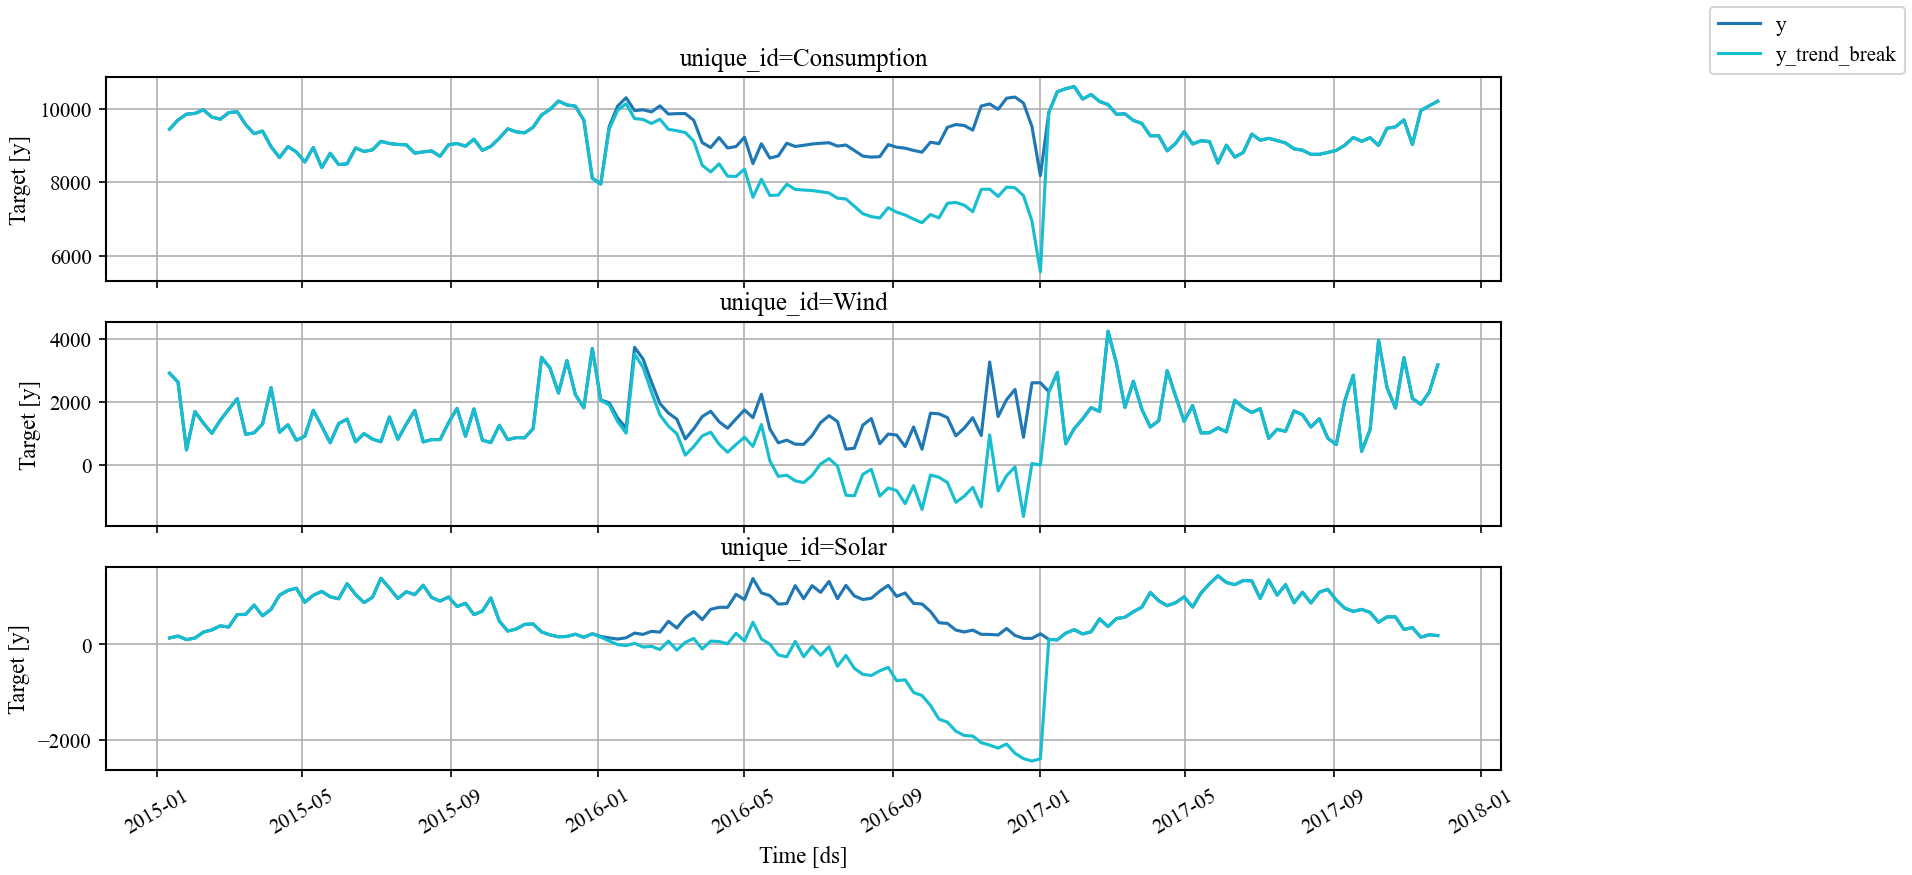

In [371]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')